In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../Modules/")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv'

dataset = read_data(path)
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,98.865052,0,17975.604018,1711.707054,3,138.640321,118.625259,179.448305,0.0,3.287901,22,96,9,NaN,20,96,13,13,10,8,9,2,9
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,68.808664,0,20223.103890,2095.505327,0,123.340767,73.893361,179.979366,0.0,2.597098,31,98,36,98.0,30,98,12,12,1,6,7,2,0
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,6.674636,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,NaN,NaN,31.010417,0,3349.163297,962.563555,2,115.090911,25.935036,177.527387,0.0,3.315256,22,85,20,85.0,20,85,9,9,4,1,1,2,0
3,21.719540,39.504234,2,2010,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,4.554370,7.839973,1.268766,-3.042901,13.286678,3.211945,2.916904,NaN,NaN,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,310.442081,79.217105,151.965634,370.323392,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,445.038062,0,17975.604018,1711.707054,3,138.640321,118.625259,179.448305,0.0,3.287901,22,96,9,NaN,20,96,13,13,10,8,9,2,9
4,22.405497,39.703383,2,2010,2010-02,EL61,θεσσαλια,EL612,λαρισα,0.32133,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.868979,11.048597,2.689361,-2.894380,15.076065,6.001348,4.861217,NaN,NaN,10.127192,9.095389,NaN,NaN,1.875504,0.5

In [4]:
dataset.shape

(468, 96)

In [5]:
dataset = encode_cyclical(dataset, 'month', 12)
dataset = convert_multiple_cases(dataset, target_col='cases')

In [6]:
## Simple output binarization

# dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)
# dataset

In [7]:
dataset.cases.unique()

array([0, 1], dtype=int64)

In [8]:
dataset.shape

(588, 98)

In [9]:
dataset.rename(columns={"cases": "case"}, inplace=True)

In [10]:
dataset.columns

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [11]:
print(f'Number of NUTS3 Units in {NUTS2}: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in Thessaly: 3


In [12]:
dsc = dataframe_describe(dataset, target_column = 'case')
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,33,9,42,7.14%
1,2011,29,30,59,10.03%
2,2012,36,0,36,6.12%
3,2013,36,0,36,6.12%
4,2014,36,0,36,6.12%
5,2015,36,0,36,6.12%
6,2016,36,0,36,6.12%
7,2017,36,0,36,6.12%
8,2018,34,7,41,6.97%
9,2019,30,53,83,14.12%


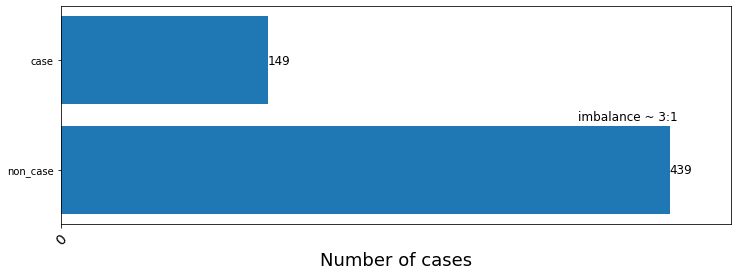

In [13]:
plot_imbalance(dataset, target_column='case')

In [14]:
majority_class = 0
near_u = 0
smote = 0
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = [year for year in range(2012, 2018)]
features_to_remove = ['x', 'y','month', 'year',]

In [15]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'mosq_pred', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_m

In [16]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler_key = scaler, majority_class = majority_class, exclude_features=features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)
    
    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, spatial_col = 'NUTS3_NAME')
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:1 || ##
Year: 2011 || w0:1, w1:2 || ##
Year: 2012 || w0:1, w1:1 || ##
Year: 2013 || w0:1, w1:1 || ##
Year: 2014 || w0:1, w1:1 || ##
Year: 2015 || w0:1, w1:1 || ##
Year: 2016 || w0:1, w1:1 || ##
Year: 2017 || w0:1, w1:1 || ##
Year: 2018 || w0:1, w1:1 || ##
Year: 2019 || w0:1, w1:2 || ##
Year: 2020 || w0:1, w1:1 || ##
Year: 2021 || w0:1, w1:1 || ##
Year: 2022 || w0:1, w1:2 || ##


In [17]:
feature_names

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'mosq_pred', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_m

In [18]:
len(feature_names)

88

In [19]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9',
               'bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

weather = ['lst', 'lst_day', 'lst_night',
           'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean',
           'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
           'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
           'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
           'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
           'acc_rainfall_2week', 'acc_rainfall_jan']

indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
            'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
            'ndbi_std',]

demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']

vectors = ['mosq_pred']

trade = ['L_TOTAL',	'UNL_TOTAL']

economic = ['MIO_EUR']

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment', 'lc_prop2',
                    'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment', 'lc_type1',
                    'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',]

spatiotemporal = ['month_sin', 'month_cos', 'x', 'y','month', 'year',]

In [20]:
len(indicies + weather + demographic + bioclimatic + spatiotemporal + vectors + trade + economic + geomorphological)

92

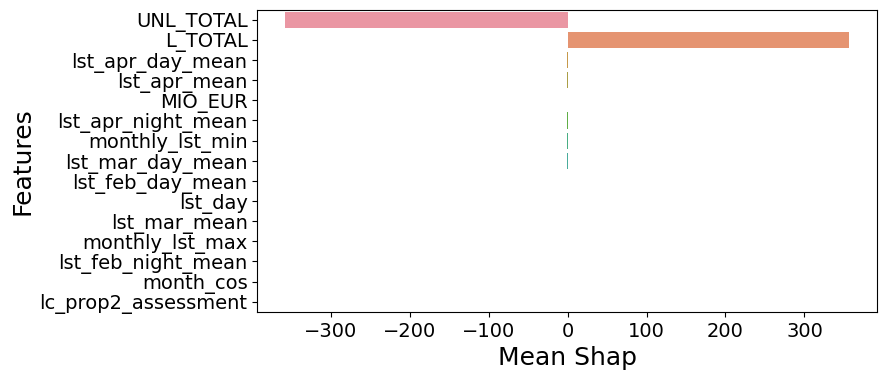

In [21]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

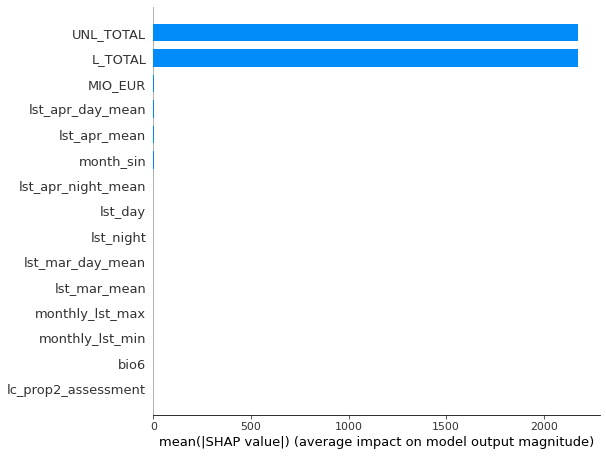

In [22]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

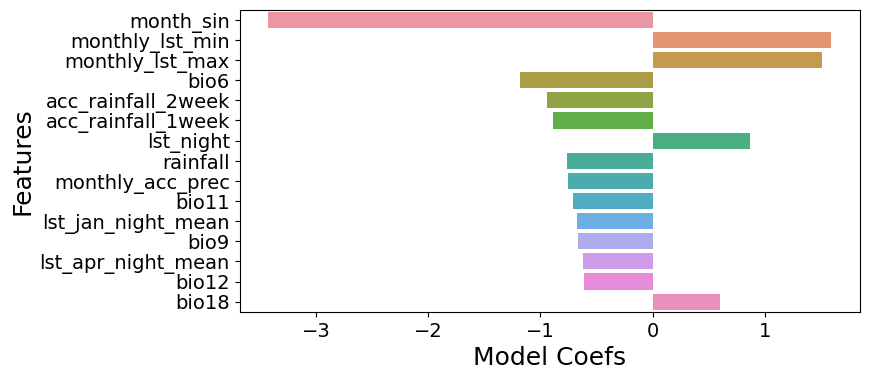

In [23]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

,features,weights
6,trade,356.830631
7,economic,0.100947
1,weather,0.035855
5,vectors,0.020062
4,spatiotemporal,0.017659
3,bioclimatic,0.005262
8,geomorphological,0.004453
0,rs_indicies,0.003496
2,demographic,0.002445


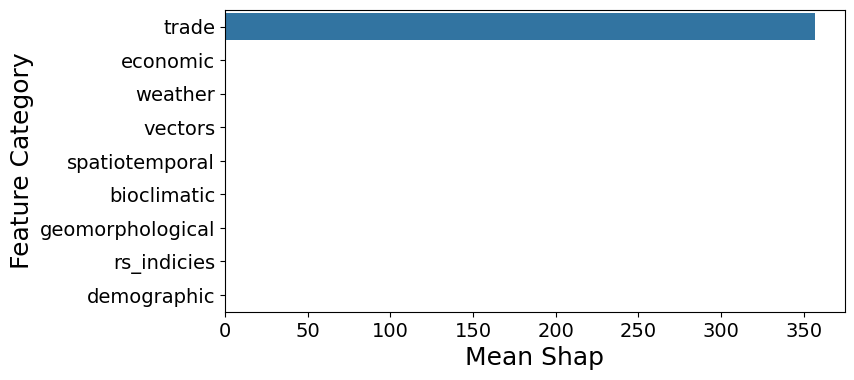

In [24]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 
                           'demographic', 'bioclimatic', 
                           'spatiotemporal', 'vectors',
                           'trade', 'economic', 'geomorphological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_bioclimatic.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_trade.weights_abs.mean(),df_economic.weights_abs.mean(),
                            df_geomorphological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,9)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

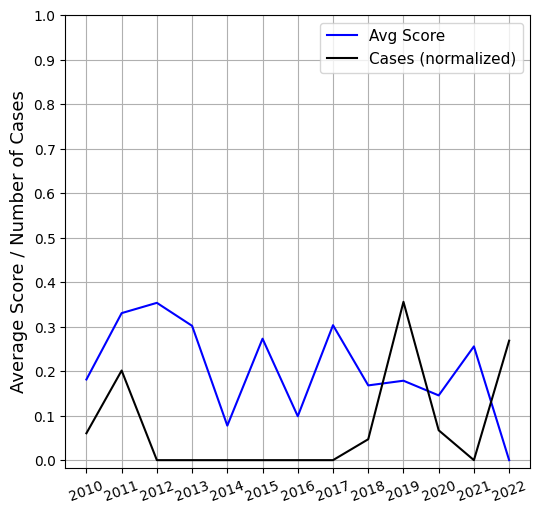

In [25]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

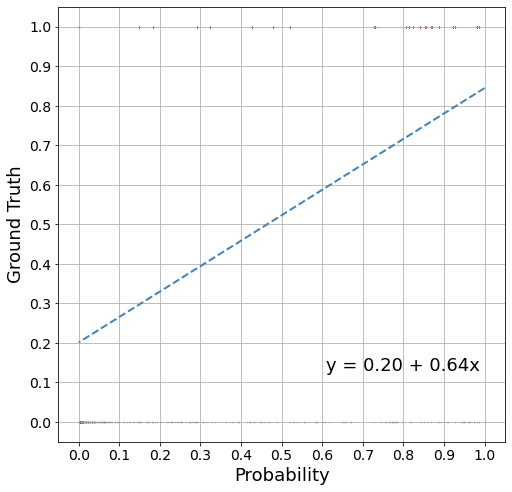

(0.20144500958967318, 0.6432513849935696)

In [26]:
plot_probability_curve(results_test)

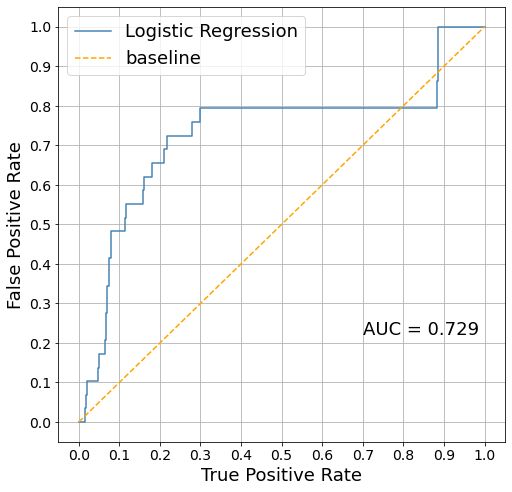

(0.2164, 0.7241, 0.2924, 0.7533)

In [27]:
plot_roc_curve(results_test, plot_gmean=False)

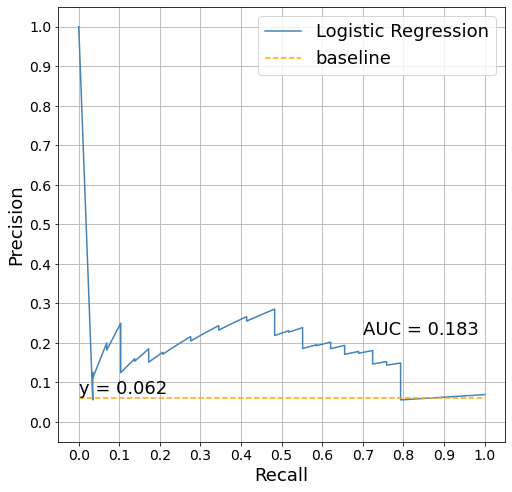

(0.7241, 0.18, 0.29, 0.4526)

In [28]:
plot_pr_curve(results_test, plot_fbeta = False)

In [29]:
results_test

,NUTS3_NAME,month,year,case,score
0,"μαγνησια, σποραδες",11,2021,0,1.000000e+00
1,λαρισα,11,2021,0,1.000000e+00
2,λαρισα,12,2021,0,1.000000e+00
3,"καρδιτσα, τρικαλα",12,2021,0,1.000000e+00
4,"μαγνησια, σποραδες",12,2021,0,1.000000e+00
...,...,...,...,...,...
463,"καρδιτσα, τρικαλα",1,2013,0,1.983934e-86
464,"καρδιτσα, τρικαλα",2,2013,0,1.348695e-86
465,"μαγνησια, σποραδες",2,2013,0,1.202866e-86
466,"μαγνησια, σποραδες",1,2014,0,8.483695e-87


In [30]:
results_test.head(30)

,NUTS3_NAME,month,year,case,score
0,"μαγνησια, σποραδες",11,2021,0,1.000000
1,λαρισα,11,2021,0,1.000000
2,λαρισα,12,2021,0,1.000000
3,"καρδιτσα, τρικαλα",12,2021,0,1.000000
4,"μαγνησια, σποραδες",12,2021,0,1.000000
5,"καρδιτσα, τρικαλα",11,2021,0,1.000000
6,λαρισα,8,2013,0,0.986854
7,λαρισα,8,2011,1,0.985904
8,λαρισα,8,2012,0,0.985152
9,λαρισα,7,2011,1,0.981818
